# (6_1) Single WSI Curriculum Training — Convergence Verification

## Goal
Train on a single WSI (tumor_011) with progressively increasing start-to-tumor distance to check whether the agent's navigation generalizes across distance ranges.

| Stage | Start Distance | Stopping Condition |
|-------|---------------|--------------------|
| 2a    | 3–5 steps     | stable at high SR  |
| 2b    | 5–10 steps    | stable convergence |
| 2c    | 10–20 steps   | stable convergence |

## Setup
- **Action space**: {UP, DOWN, LEFT, RIGHT} — 4 actions, no STOP
- **Termination**: step on tumor → success; exceed max_steps → timeout
- **Reward**: tumor +50, step −0.01, revisit −0.2, timeout −1.0, background −0.5
- **Workflow**: train each stage to convergence, save the model, evaluate + plot trajectories, then continue to the next stage

## 1. Setup & Imports

In [ ]:
import os, time, datetime, importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# RL
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# Project environment
import wsi_env as wsi_env_module
importlib.reload(wsi_env_module)
from wsi_env import WSIEnv

# Paths & constants
H5_PATH = "tile_database/tumor_011.h5"
MAX_STEPS = 2000
EMBEDDING_SUFFIX = "_i"
RUN_TAG = f"cur1_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

REWARD_CFG = dict(
    step_penalty=-0.01,
    revisit_penalty=-0.2,
    tumor_reward=50.0,
    timeout_penalty=-1.0,
    background_penalty=-0.5,
)

# PPO hyper-parameters
PPO_KWARGS = dict(
    policy="MlpPolicy",
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    device="cpu",
    seed=42,
)

print(f"Run tag : {RUN_TAG}")
print(f"H5      : {H5_PATH}")
print(f"Reward  : {REWARD_CFG}")
print(f"PPO     : lr={PPO_KWARGS['learning_rate']}, gamma={PPO_KWARGS['gamma']}, "
      f"ent_coef={PPO_KWARGS['ent_coef']}, n_steps={PPO_KWARGS['n_steps']}")

Run tag : cur1_20260323_104751
H5      : tile_database/tumor_011.h5
Reward  : {'step_penalty': -0.01, 'revisit_penalty': -0.2, 'tumor_reward': 50.0, 'timeout_penalty': -1.0, 'background_penalty': -0.5}
PPO     : lr=0.0003, gamma=0.995, ent_coef=0.01, n_steps=2048


In [ ]:
# Callback: track episode stats & print periodically
class TrainingCallback(BaseCallback):
    """Track episode stats and print progress at fixed step intervals."""

    def __init__(self, check_freq: int = 5000, window: int = 50, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.window = window
        self.episode_rewards: list[float] = []
        self.episode_lengths: list[int] = []
        self.successes: list[bool] = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])
        if dones is not None:
            for i, done in enumerate(dones):
                if done and infos is not None and i < len(infos):
                    ep = infos[i].get("episode")
                    if ep is not None:
                        self.episode_rewards.append(float(ep["r"]))
                        self.episode_lengths.append(int(ep["l"]))
                    self.successes.append(infos[i].get("success", False))

        if self.num_timesteps % self.check_freq == 0 and len(self.episode_rewards) > 0:
            n = min(self.window, len(self.episode_rewards))
            avg_r = np.mean(self.episode_rewards[-n:])
            avg_l = np.mean(self.episode_lengths[-n:])
            sr = np.mean(self.successes[-n:]) * 100
            print(f"[Step {self.num_timesteps:>8d}]  last{n:>3d}  "
                  f"avg_R={avg_r:+.2f}  avg_L={avg_l:.0f}  SR={sr:.1f}%  "
                  f"total_eps={len(self.episode_rewards)}")
        return True

    def _on_training_end(self):
        n = len(self.episode_rewards)
        if n > 0:
            last = min(50, n)
            print(f"  Training done: {n} eps, "
                  f"last{last} avg_R={np.mean(self.episode_rewards[-last:]):+.2f}  "
                  f"avg_L={np.mean(self.episode_lengths[-last:]):.0f}  "
                  f"SR={np.mean(self.successes[-last:])*100:.1f}%")


# Evaluation function
def evaluate_from_pool(model, h5_path, dist_range, n_episodes=50,
                       max_steps=2000, seed=123):
    """Deterministic evaluation from sampled starting positions within a distance band."""
    eval_env = WSIEnv(
        h5_path=h5_path,
        max_steps=max_steps,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode="distance_band",
        start_dist_range=dist_range,
    )

    rng = np.random.RandomState(seed)
    pool = eval_env.get_start_pool(dist_range[0], dist_range[1])

    indices = rng.choice(len(pool), size=min(n_episodes, len(pool)), replace=False)
    starts = [(int(pool[i][0]), int(pool[i][1])) for i in indices]

    results = []
    for start in starts:
        eval_env.fixed_starts = [start]
        eval_env.start_mode = "fixed"
        eval_env._start_idx = 0

        obs, info = eval_env.reset()
        trajectory = [(info["row"], info["col"])]
        total_r = 0.0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            trajectory.append((info["row"], info["col"]))
            total_r += reward
            done = terminated or truncated

        results.append({
            "start": start,
            "trajectory": trajectory,
            "reward": total_r,
            "length": len(trajectory) - 1,
            "success": info.get("success", False),
        })

    eval_env.close()
    return results


# Trajectory visualization function
def plot_trajectories(results, env_for_grid, title, n_show=4, seed=42):
    """Plot sample trajectories (mix of success & fail) on the WSI grid."""
    rng = np.random.RandomState(seed)
    success_eps = [ep for ep in results if ep["success"]]
    fail_eps = [ep for ep in results if not ep["success"]]

    # Pick a mix: up to ceil(n_show/2) success + rest fail
    n_succ = min(len(success_eps), (n_show + 1) // 2)
    n_fail = min(len(fail_eps), n_show - n_succ)
    n_succ = min(len(success_eps), n_show - n_fail)  # fill remaining with success if needed

    show_eps = []
    if n_succ > 0:
        idx_s = rng.choice(len(success_eps), size=n_succ, replace=False)
        show_eps += [success_eps[i] for i in idx_s]
    if n_fail > 0:
        idx_f = rng.choice(len(fail_eps), size=n_fail, replace=False)
        show_eps += [fail_eps[i] for i in idx_f]

    if len(show_eps) == 0:
        print(f"  No episodes to show for: {title}")
        return

    cols = len(show_eps)
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
    if cols == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13)

    ug = env_for_grid  # unwrapped grid env

    for i, ep in enumerate(show_eps):
        ax = axes[i]
        traj = ep["trajectory"]
        traj_r = [t[0] for t in traj]
        traj_c = [t[1] for t in traj]

        margin = 5
        r_min = max(0, min(traj_r) - margin)
        r_max = min(ug.n_rows, max(traj_r) + margin)
        c_min = max(0, min(traj_c) - margin)
        c_max = min(ug.n_cols, max(traj_c) + margin)

        local_tissue = ug.tissue_grid[r_min:r_max, c_min:c_max]
        local_tumor = ug.tumor_grid[r_min:r_max, c_min:c_max]

        canvas = np.ones((*local_tissue.shape, 3))
        canvas[local_tissue] = [0.9, 0.9, 0.9]
        canvas[local_tumor] = [1.0, 0.7, 0.7]
        ax.imshow(canvas, origin="upper")

        sr_list = [r - r_min for r in traj_r]
        sc_list = [c - c_min for c in traj_c]

        # Color gradient: blue (early) → red (late)
        n_seg = len(sr_list) - 1
        if n_seg > 0:
            cmap = plt.cm.coolwarm
            for s in range(n_seg):
                ax.plot(sc_list[s:s+2], sr_list[s:s+2],
                        color=cmap(s / max(n_seg - 1, 1)), alpha=0.6, lw=1.2)

        ax.plot(sc_list[0], sr_list[0], "go", ms=10, zorder=5)
        ax.plot(sc_list[-1], sr_list[-1], "r*", ms=12, zorder=5)

        status = "OK" if ep["success"] else "TO"
        ax.set_title(f"{status} | R={ep['reward']:+.1f} | L={ep['length']}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()


print("Callback, evaluate_from_pool, plot_trajectories defined.")

Callback, evaluate_from_pool, plot_trajectories defined.


## 2. Environment & BFS Distance Pool Inspection

Check the candidate pool size for each distance band to confirm there are enough starting positions for training.

Grid size      : 493 x 218
Tissue tiles   : 24347
Tumor tiles    : 1108
Tumor regions  : 13

Stage            Pool size  BFS d_min  BFS d_max
--------------------------------------------------
2a (3-5)               884         3         5
2b (5-10)             1733         5        10
2c (10-20)            3343        10        20

Reachable non-tumor tissue: 19608 / 23239
BFS distance range: [1, 125]


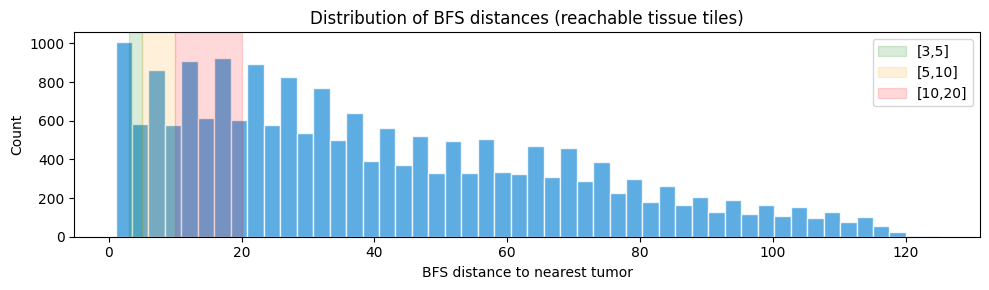

In [3]:
# Create a temporary env to inspect the grid & BFS distance pools
_tmp_env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=MAX_STEPS,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    start_mode="distance_band",
    start_dist_range=(3, 5),
    reward_cfg=REWARD_CFG,
)

print(f"Grid size      : {_tmp_env.n_rows} x {_tmp_env.n_cols}")
print(f"Tissue tiles   : {_tmp_env.tissue_grid.sum()}")
print(f"Tumor tiles    : {_tmp_env.tumor_grid.sum()}")
print(f"Tumor regions  : {_tmp_env.n_tumor_regions}")
print()

# Stage distance pools
stage_pools = {
    "2a (3-5)":   (3, 5),
    "2b (5-10)":  (5, 10),
    "2c (10-20)": (10, 20),
}

print(f"{'Stage':<15} {'Pool size':>10}  {'BFS d_min':>8}  {'BFS d_max':>8}")
print("-" * 50)
for name, (d_lo, d_hi) in stage_pools.items():
    pool = _tmp_env.get_start_pool(d_lo, d_hi)
    if len(pool) > 0:
        dists = _tmp_env._dist_to_tumor[pool[:, 0], pool[:, 1]]
        print(f"{name:<15} {len(pool):>10}  {dists.min():>8}  {dists.max():>8}")
    else:
        print(f"{name:<15} {len(pool):>10}  {'N/A':>8}  {'N/A':>8}")

# Also show BFS distance distribution
dist_map = _tmp_env._dist_to_tumor
tissue_dists = dist_map[_tmp_env.tissue_grid & ~_tmp_env.tumor_grid]
reachable = tissue_dists[tissue_dists >= 0]
print(f"\nReachable non-tumor tissue: {len(reachable)} / {len(tissue_dists)}")
print(f"BFS distance range: [{reachable.min()}, {reachable.max()}]")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.hist(reachable, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
ax.set_xlabel("BFS distance to nearest tumor")
ax.set_ylabel("Count")
ax.set_title("Distribution of BFS distances (reachable tissue tiles)")
for (d_lo, d_hi), color in zip([(3,5),(5,10),(10,20)], ["green","orange","red"]):
    ax.axvspan(d_lo, d_hi, alpha=0.15, color=color, label=f"[{d_lo},{d_hi}]")
ax.legend()
plt.tight_layout()
plt.show()

_tmp_env.close()
del _tmp_env

## 3. Stage 2a — Start Distance 3–5 Steps

Closest distance band. 1M steps should be sufficient to reach a stable success rate from this range.

In [ ]:
# Stage 2a: distance_band (3, 5), train 1M steps
STAGE_2A_DIST = (3, 5)
STAGE_2A_STEPS = 1_000_000

monitor_dir_2a = f"monitor_logs_{RUN_TAG}_2a"
os.makedirs(monitor_dir_2a, exist_ok=True)

env_2a = Monitor(
    WSIEnv(
        h5_path=H5_PATH,
        max_steps=MAX_STEPS,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode="distance_band",
        start_dist_range=STAGE_2A_DIST,
        reward_cfg=REWARD_CFG,
    ),
    filename=os.path.join(monitor_dir_2a, "monitor"),
)

model_2a = PPO(env=env_2a, **PPO_KWARGS)
print(f"Model params: {sum(p.numel() for p in model_2a.policy.parameters()):,}")
print(f"Obs dim: {env_2a.observation_space.shape[0]}, Actions: {env_2a.action_space.n}")
print(f"Stage 2a: distance_band={STAGE_2A_DIST}, total_timesteps={STAGE_2A_STEPS:,}")

cb_2a = TrainingCallback(check_freq=10_000, window=50)
t0 = time.time()
model_2a.learn(total_timesteps=STAGE_2A_STEPS, callback=cb_2a, progress_bar=False)
elapsed_2a = time.time() - t0
print(f"\nStage 2a training done in {elapsed_2a/60:.1f} min")

Model params: 221,253
Obs dim: 1660, Actions: 4
Stage 2a: distance_band=(3, 5), total_timesteps=1,000,000
[Step    10000]  last 50  avg_R=+27.12  avg_L=159  SR=98.0%  total_eps=52
[Step    20000]  last 50  avg_R=+21.15  avg_L=253  SR=90.0%  total_eps=83
[Step    30000]  last 50  avg_R=+12.45  avg_L=359  SR=86.0%  total_eps=103
[Step    40000]  last 50  avg_R=+18.94  avg_L=384  SR=84.0%  total_eps=132
[Step    50000]  last 50  avg_R=+12.45  avg_L=500  SR=76.0%  total_eps=149
[Step    60000]  last 50  avg_R=+13.32  avg_L=501  SR=76.0%  total_eps=169
[Step    70000]  last 50  avg_R=+12.62  avg_L=576  SR=72.0%  total_eps=183
[Step    80000]  last 50  avg_R=+20.40  avg_L=579  SR=72.0%  total_eps=197
[Step    90000]  last 50  avg_R=+31.58  avg_L=422  SR=80.0%  total_eps=224
[Step   100000]  last 50  avg_R=+30.65  avg_L=458  SR=78.0%  total_eps=244
[Step   110000]  last 50  avg_R=+23.70  avg_L=506  SR=76.0%  total_eps=265
[Step   120000]  last 50  avg_R=+27.59  avg_L=312  SR=86.0%  total_eps=

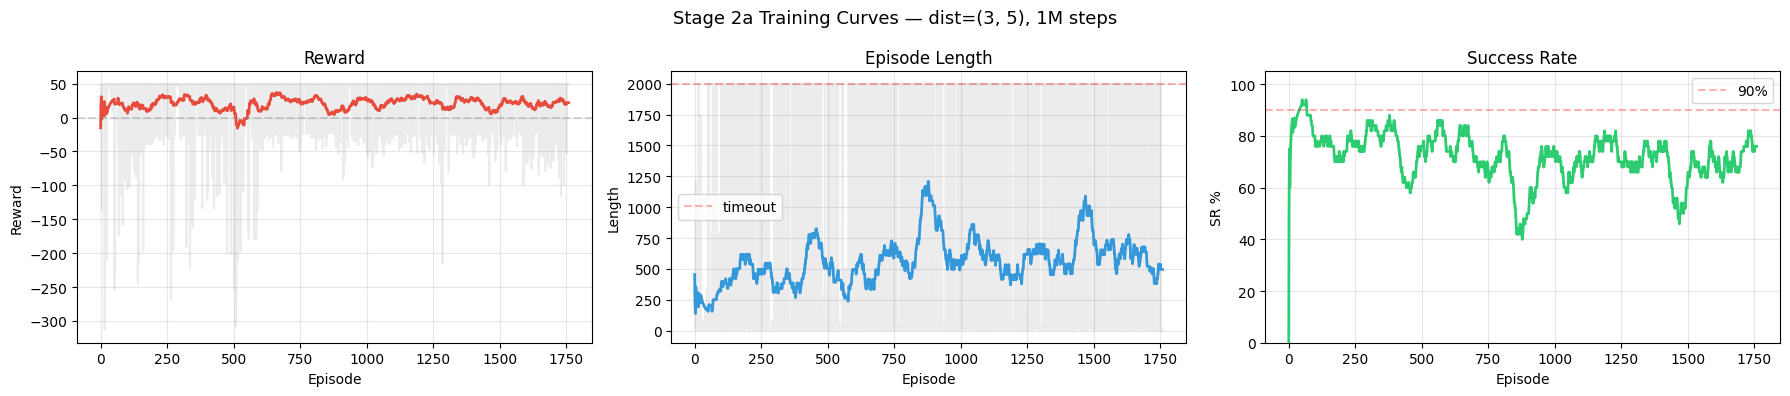

Total episodes: 1760
Last 50: avg_R=+21.97  avg_L=496.3  SR=76.0%


In [ ]:
# Stage 2a: training curves
# SB3 Monitor saves as <filename>.monitor.csv
csv_2a = [f for f in os.listdir(monitor_dir_2a) if f.endswith(".csv")][0]
df_2a = pd.read_csv(os.path.join(monitor_dir_2a, csv_2a), skiprows=1)
df_2a.columns = ["r", "l", "t"]
W = 50
df_2a["r_ma"] = df_2a["r"].rolling(W, min_periods=1).mean()
df_2a["l_ma"] = df_2a["l"].rolling(W, min_periods=1).mean()
df_2a["success"] = (df_2a["r"] > 0).astype(float)
df_2a["sr_ma"] = df_2a["success"].rolling(W, min_periods=1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f"Stage 2a Training Curves — dist={STAGE_2A_DIST}, {STAGE_2A_STEPS/1e6:.0f}M steps", fontsize=13)

axes[0].plot(df_2a["r"], alpha=0.15, color="gray")
axes[0].plot(df_2a["r_ma"], color="#e74c3c", lw=2)
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Reward"); axes[0].set_title("Reward")
axes[0].axhline(0, color="gray", ls="--", alpha=0.3)

axes[1].plot(df_2a["l"], alpha=0.15, color="gray")
axes[1].plot(df_2a["l_ma"], color="#3498db", lw=2)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Length"); axes[1].set_title("Episode Length")
axes[1].axhline(MAX_STEPS, color="red", ls="--", alpha=0.3, label="timeout")
axes[1].legend()

axes[2].plot(df_2a["sr_ma"], color="#2ecc71", lw=2)
axes[2].set_xlabel("Episode"); axes[2].set_ylabel("SR %"); axes[2].set_title("Success Rate")
axes[2].axhline(90, color="red", ls="--", alpha=0.3, label="90%")
axes[2].set_ylim(0, 105); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_eps = len(df_2a)
last = min(50, n_eps)
print(f"Total episodes: {n_eps}")
print(f"Last {last}: avg_R={df_2a['r'].tail(last).mean():+.2f}  "

      f"avg_L={df_2a['l'].tail(last).mean():.1f}  "      f"SR={df_2a['success'].tail(last).mean()*100:.1f}%")

Stage 2a eval (50 eps, dist=(3, 5)): SR=40.0%  avg_L=1202.5  avg_R=+7.37


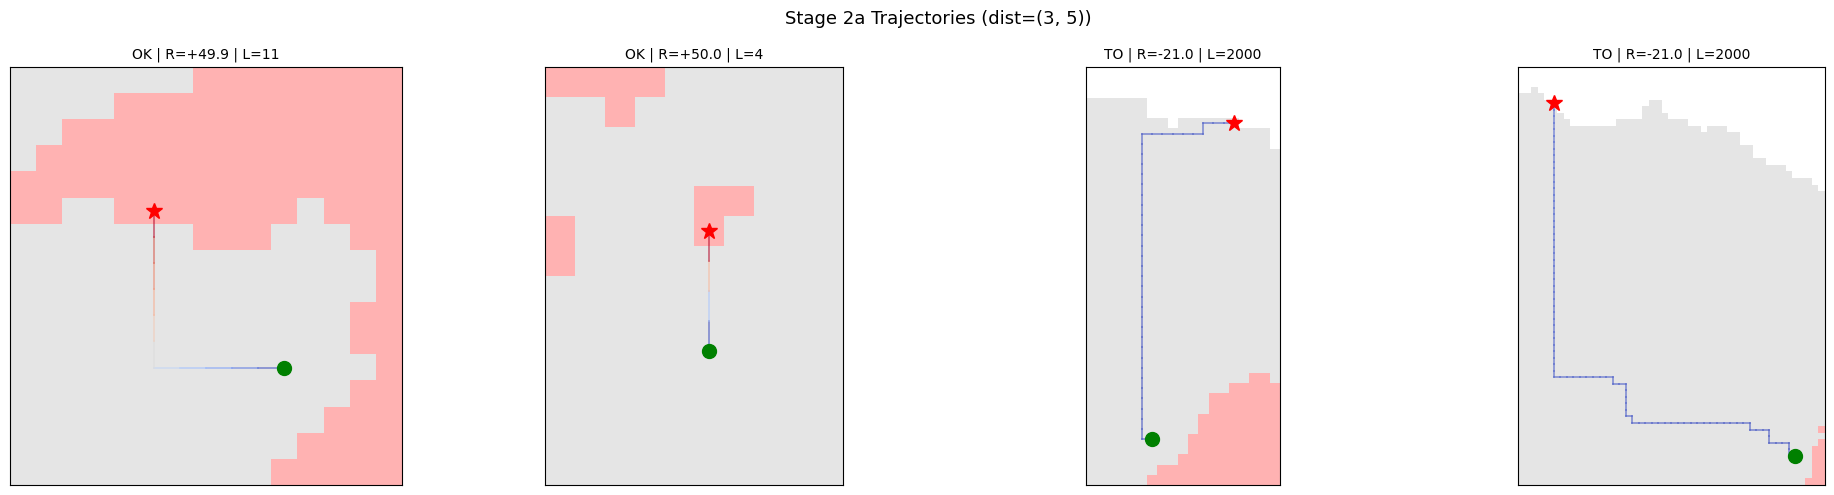

In [ ]:
# Stage 2a: deterministic evaluation & trajectory visualization
results_2a = evaluate_from_pool(model_2a, H5_PATH, STAGE_2A_DIST, n_episodes=50)
sr_2a = np.mean([r["success"] for r in results_2a]) * 100
avg_l_2a = np.mean([r["length"] for r in results_2a])
avg_r_2a = np.mean([r["reward"] for r in results_2a])
print(f"Stage 2a eval (50 eps, dist={STAGE_2A_DIST}): "
      f"SR={sr_2a:.1f}%  avg_L={avg_l_2a:.1f}  avg_R={avg_r_2a:+.2f}")

# Use the training env's unwrapped for grid data
grid_env_2a = env_2a.env if hasattr(env_2a, "env") else env_2a
plot_trajectories(results_2a, grid_env_2a, f"Stage 2a Trajectories (dist={STAGE_2A_DIST})", n_show=4)

In [ ]:
# Save Stage 2a model
save_path_2a = f"ppo_{RUN_TAG}_2a.zip"
model_2a.save(save_path_2a)
print(f"Stage 2a model saved: {save_path_2a}")

Stage 2a model saved: ppo_cur1_20260323_104751_2a.zip


## 4. Stage 2b — Start Distance 5–10 Steps

Continue from the Stage 2a model with the distance band extended to 5–10 steps. Another 1M steps.

In [ ]:
# Stage 2b: distance_band (5, 10), train 1M steps, continue from 2a
STAGE_2B_DIST = (5, 10)
STAGE_2B_STEPS = 1_000_000

monitor_dir_2b = f"monitor_logs_{RUN_TAG}_2b"
os.makedirs(monitor_dir_2b, exist_ok=True)

env_2b = Monitor(
    WSIEnv(
        h5_path=H5_PATH,
        max_steps=MAX_STEPS,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode="distance_band",
        start_dist_range=STAGE_2B_DIST,
        reward_cfg=REWARD_CFG,
    ),
    filename=os.path.join(monitor_dir_2b, "monitor"),
)

# Load stage 2a model and set new env
model_2b = PPO.load(save_path_2a, env=env_2b, device="cpu")
print(f"Stage 2b: loaded 2a model, distance_band={STAGE_2B_DIST}, total_timesteps={STAGE_2B_STEPS:,}")

cb_2b = TrainingCallback(check_freq=10_000, window=50)
t0 = time.time()
model_2b.learn(total_timesteps=STAGE_2B_STEPS, callback=cb_2b, progress_bar=False)
elapsed_2b = time.time() - t0
print(f"\nStage 2b training done in {elapsed_2b/60:.1f} min")

Stage 2b: loaded 2a model, distance_band=(5, 10), total_timesteps=1,000,000
[Step    10000]  last  9  avg_R=+14.71  avg_L=947  SR=55.6%  total_eps=9
[Step    20000]  last 22  avg_R=+15.95  avg_L=872  SR=59.1%  total_eps=22
[Step    30000]  last 35  avg_R=+14.73  avg_L=843  SR=60.0%  total_eps=35
[Step    40000]  last 43  avg_R=+10.77  avg_L=921  SR=55.8%  total_eps=43
[Step    50000]  last 50  avg_R=+9.49  avg_L=950  SR=54.0%  total_eps=52
[Step    60000]  last 50  avg_R=+8.09  avg_L=985  SR=52.0%  total_eps=62
[Step    70000]  last 50  avg_R=+5.99  avg_L=1054  SR=48.0%  total_eps=70
[Step    80000]  last 50  avg_R=+5.57  avg_L=1093  SR=46.0%  total_eps=78
[Step    90000]  last 50  avg_R=+4.67  avg_L=1132  SR=44.0%  total_eps=86
[Step   100000]  last 50  avg_R=+1.17  avg_L=1210  SR=40.0%  total_eps=92
[Step   110000]  last 50  avg_R=+2.88  avg_L=1219  SR=40.0%  total_eps=101
[Step   120000]  last 50  avg_R=+2.81  avg_L=1227  SR=42.0%  total_eps=110
[Step   130000]  last 50  avg_R=+0.93

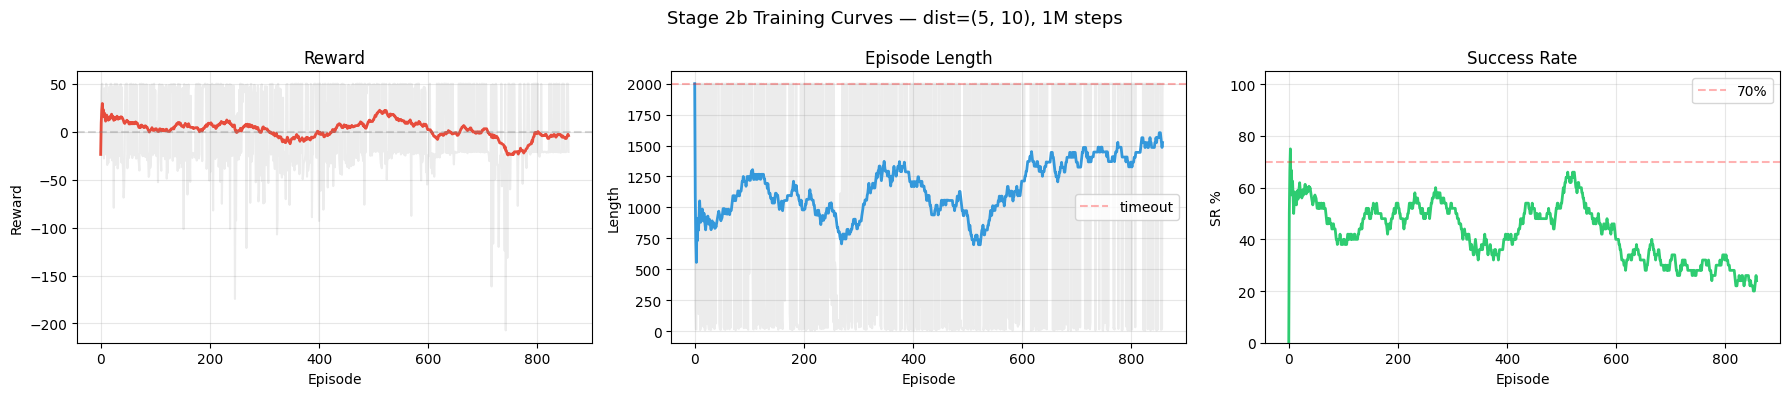

Total episodes: 858
Last 50: avg_R=-4.19  avg_L=1523.7  SR=24.0%


In [ ]:
# Stage 2b: training curves
csv_2b = [f for f in os.listdir(monitor_dir_2b) if f.endswith(".csv")][0]
df_2b = pd.read_csv(os.path.join(monitor_dir_2b, csv_2b), skiprows=1)
df_2b.columns = ["r", "l", "t"]
df_2b["r_ma"] = df_2b["r"].rolling(W, min_periods=1).mean()
df_2b["l_ma"] = df_2b["l"].rolling(W, min_periods=1).mean()
df_2b["success"] = (df_2b["r"] > 0).astype(float)
df_2b["sr_ma"] = df_2b["success"].rolling(W, min_periods=1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f"Stage 2b Training Curves — dist={STAGE_2B_DIST}, {STAGE_2B_STEPS/1e6:.0f}M steps", fontsize=13)

axes[0].plot(df_2b["r"], alpha=0.15, color="gray")
axes[0].plot(df_2b["r_ma"], color="#e74c3c", lw=2)
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Reward"); axes[0].set_title("Reward")
axes[0].axhline(0, color="gray", ls="--", alpha=0.3)

axes[1].plot(df_2b["l"], alpha=0.15, color="gray")
axes[1].plot(df_2b["l_ma"], color="#3498db", lw=2)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Length"); axes[1].set_title("Episode Length")
axes[1].axhline(MAX_STEPS, color="red", ls="--", alpha=0.3, label="timeout")
axes[1].legend()

axes[2].plot(df_2b["sr_ma"], color="#2ecc71", lw=2)
axes[2].set_xlabel("Episode"); axes[2].set_ylabel("SR %"); axes[2].set_title("Success Rate")
axes[2].axhline(70, color="red", ls="--", alpha=0.3, label="70%")
axes[2].set_ylim(0, 105); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_eps = len(df_2b)
last = min(50, n_eps)
print(f"Total episodes: {n_eps}")
print(f"Last {last}: avg_R={df_2b['r'].tail(last).mean():+.2f}  "
      f"avg_L={df_2b['l'].tail(last).mean():.1f}  "
      f"SR={df_2b['success'].tail(last).mean()*100:.1f}%")

Stage 2b eval (50 eps, dist=(5, 10)): SR=44.0%  avg_L=1124.9  avg_R=+10.19
Stage 2b model on 2a pool (dist=(3, 5)): SR=48.0%  (forgetting check: 2a was 40.0%)


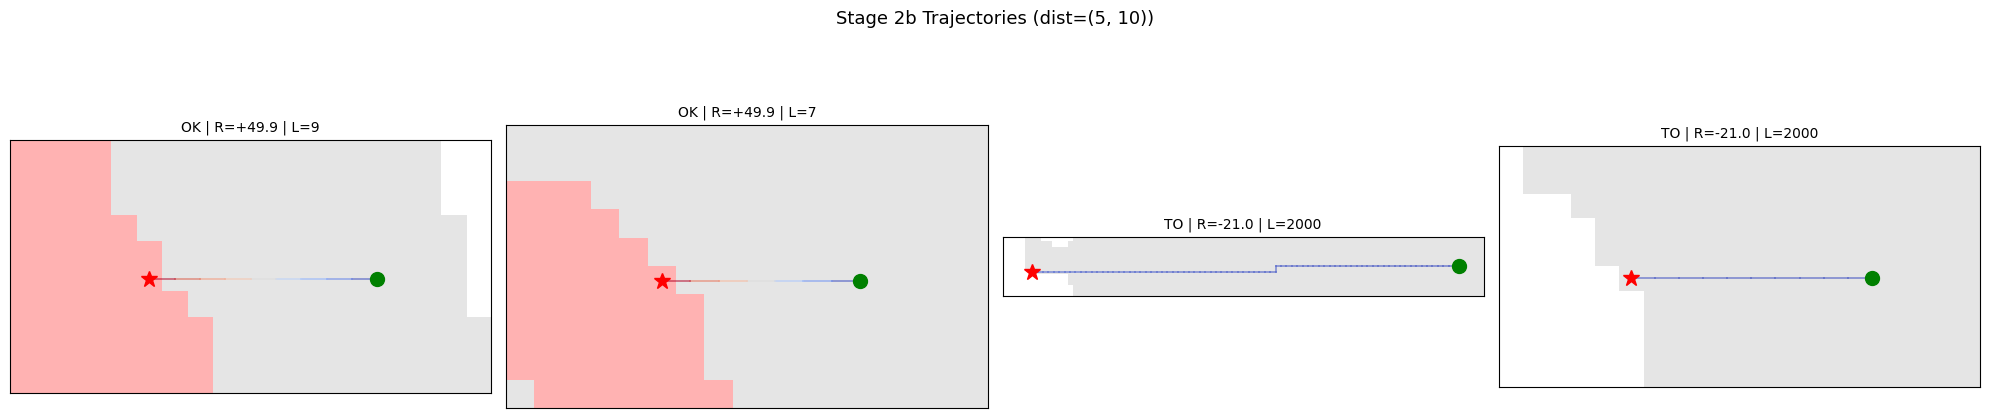

In [ ]:
# Stage 2b: evaluation & trajectory viz
results_2b = evaluate_from_pool(model_2b, H5_PATH, STAGE_2B_DIST, n_episodes=50)
sr_2b = np.mean([r["success"] for r in results_2b]) * 100
avg_l_2b = np.mean([r["length"] for r in results_2b])
avg_r_2b = np.mean([r["reward"] for r in results_2b])
print(f"Stage 2b eval (50 eps, dist={STAGE_2B_DIST}): "
      f"SR={sr_2b:.1f}%  avg_L={avg_l_2b:.1f}  avg_R={avg_r_2b:+.2f}")

# Also test on 2a range to check catastrophic forgetting
results_2b_on_2a = evaluate_from_pool(model_2b, H5_PATH, STAGE_2A_DIST, n_episodes=50)
sr_2b_on_2a = np.mean([r["success"] for r in results_2b_on_2a]) * 100
print(f"Stage 2b model on 2a pool (dist={STAGE_2A_DIST}): SR={sr_2b_on_2a:.1f}%  "
      f"(forgetting check: 2a was {sr_2a:.1f}%)")

grid_env_2b = env_2b.env if hasattr(env_2b, "env") else env_2b
plot_trajectories(results_2b, grid_env_2b, f"Stage 2b Trajectories (dist={STAGE_2B_DIST})", n_show=4)

In [ ]:
# Save Stage 2b model
save_path_2b = f"ppo_{RUN_TAG}_2b.zip"
model_2b.save(save_path_2b)
print(f"Stage 2b model saved: {save_path_2b}")

Stage 2b model saved: ppo_cur1_20260323_104751_2b.zip


## 5. Stage 2c — Start Distance 10–20 Steps

Continue from Stage 2b into the far-distance band. 1M steps.

In [ ]:
# Stage 2c: distance_band (10, 20), train 1M steps, continue from 2b
STAGE_2C_DIST = (10, 20)
STAGE_2C_STEPS = 1_000_000

monitor_dir_2c = f"monitor_logs_{RUN_TAG}_2c"
os.makedirs(monitor_dir_2c, exist_ok=True)

env_2c = Monitor(
    WSIEnv(
        h5_path=H5_PATH,
        max_steps=MAX_STEPS,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode="distance_band",
        start_dist_range=STAGE_2C_DIST,
        reward_cfg=REWARD_CFG,
    ),
    filename=os.path.join(monitor_dir_2c, "monitor"),
)

# Load stage 2b model and set new env
model_2c = PPO.load(save_path_2b, env=env_2c, device="cpu")
print(f"Stage 2c: loaded 2b model, distance_band={STAGE_2C_DIST}, total_timesteps={STAGE_2C_STEPS:,}")

cb_2c = TrainingCallback(check_freq=10_000, window=50)
t0 = time.time()
model_2c.learn(total_timesteps=STAGE_2C_STEPS, callback=cb_2c, progress_bar=False)
elapsed_2c = time.time() - t0
print(f"\nStage 2c training done in {elapsed_2c/60:.1f} min")

Stage 2c: loaded 2b model, distance_band=(10, 20), total_timesteps=1,000,000
[Step    10000]  last  5  avg_R=-21.08  avg_L=2000  SR=0.0%  total_eps=5
[Step    20000]  last 10  avg_R=-14.06  avg_L=1802  SR=10.0%  total_eps=10
[Step    30000]  last 15  avg_R=-16.37  avg_L=1868  SR=6.7%  total_eps=15
[Step    40000]  last 23  avg_R=-8.80  avg_L=1657  SR=17.4%  total_eps=23
[Step    50000]  last 29  avg_R=-8.88  avg_L=1660  SR=17.2%  total_eps=29
[Step    60000]  last 36  avg_R=-7.31  avg_L=1616  SR=19.4%  total_eps=36
[Step    70000]  last 45  avg_R=-3.76  avg_L=1518  SR=24.4%  total_eps=45
[Step    80000]  last 50  avg_R=-5.49  avg_L=1566  SR=22.0%  total_eps=50
[Step    90000]  last 50  avg_R=+8.58  avg_L=1181  SR=42.0%  total_eps=66
[Step   100000]  last 50  avg_R=+8.57  avg_L=1182  SR=42.0%  total_eps=74
[Step   110000]  last 50  avg_R=+9.99  avg_L=1143  SR=44.0%  total_eps=81
[Step   120000]  last 50  avg_R=+12.82  avg_L=1064  SR=48.0%  total_eps=90
[Step   130000]  last 50  avg_R=+7

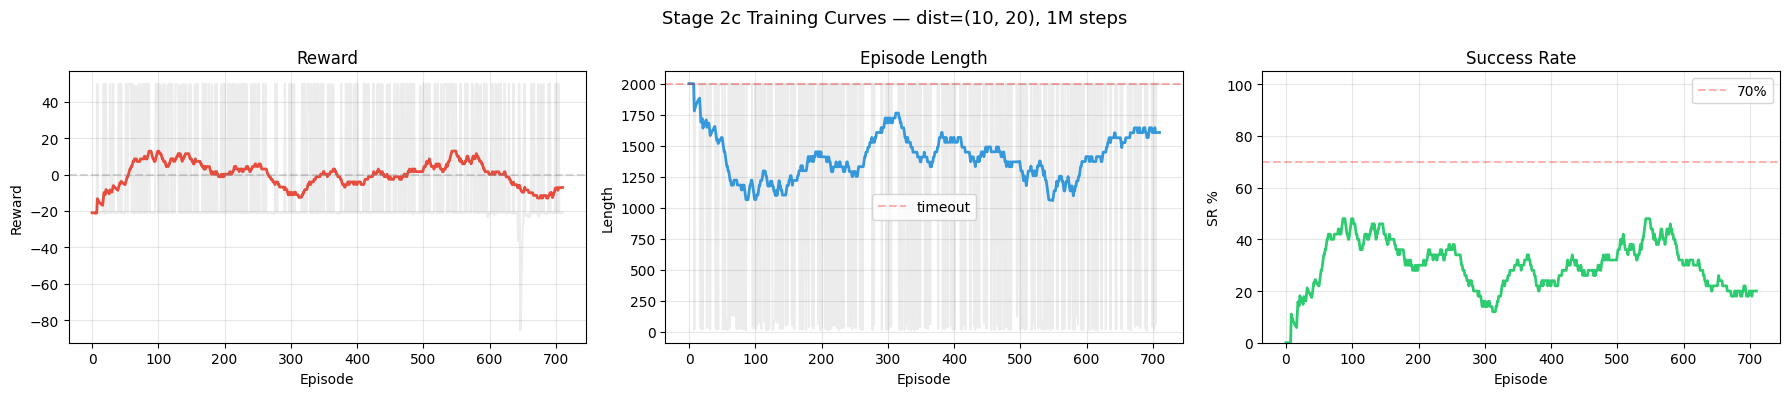

Total episodes: 711
Last 50: avg_R=-7.10  avg_L=1606.1  SR=20.0%


In [ ]:
# Stage 2c: training curves
csv_2c = [f for f in os.listdir(monitor_dir_2c) if f.endswith(".csv")][0]
df_2c = pd.read_csv(os.path.join(monitor_dir_2c, csv_2c), skiprows=1)
df_2c.columns = ["r", "l", "t"]
df_2c["r_ma"] = df_2c["r"].rolling(W, min_periods=1).mean()
df_2c["l_ma"] = df_2c["l"].rolling(W, min_periods=1).mean()
df_2c["success"] = (df_2c["r"] > 0).astype(float)
df_2c["sr_ma"] = df_2c["success"].rolling(W, min_periods=1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f"Stage 2c Training Curves — dist={STAGE_2C_DIST}, {STAGE_2C_STEPS/1e6:.0f}M steps", fontsize=13)

axes[0].plot(df_2c["r"], alpha=0.15, color="gray")
axes[0].plot(df_2c["r_ma"], color="#e74c3c", lw=2)
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Reward"); axes[0].set_title("Reward")
axes[0].axhline(0, color="gray", ls="--", alpha=0.3)

axes[1].plot(df_2c["l"], alpha=0.15, color="gray")
axes[1].plot(df_2c["l_ma"], color="#3498db", lw=2)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Length"); axes[1].set_title("Episode Length")
axes[1].axhline(MAX_STEPS, color="red", ls="--", alpha=0.3, label="timeout")
axes[1].legend()

axes[2].plot(df_2c["sr_ma"], color="#2ecc71", lw=2)
axes[2].set_xlabel("Episode"); axes[2].set_ylabel("SR %"); axes[2].set_title("Success Rate")
axes[2].axhline(70, color="red", ls="--", alpha=0.3, label="70%")
axes[2].set_ylim(0, 105); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_eps = len(df_2c)
last = min(50, n_eps)
print(f"Total episodes: {n_eps}")
print(f"Last {last}: avg_R={df_2c['r'].tail(last).mean():+.2f}  "
      f"avg_L={df_2c['l'].tail(last).mean():.1f}  "
      f"SR={df_2c['success'].tail(last).mean()*100:.1f}%")

Stage 2c eval (50 eps, dist=(10, 20)): SR=40.0%  avg_L=1220.2  avg_R=+7.20
Stage 2c model on 2a pool: SR=66.0% (was 40.0%)
Stage 2c model on 2b pool: SR=38.0% (was 44.0%)


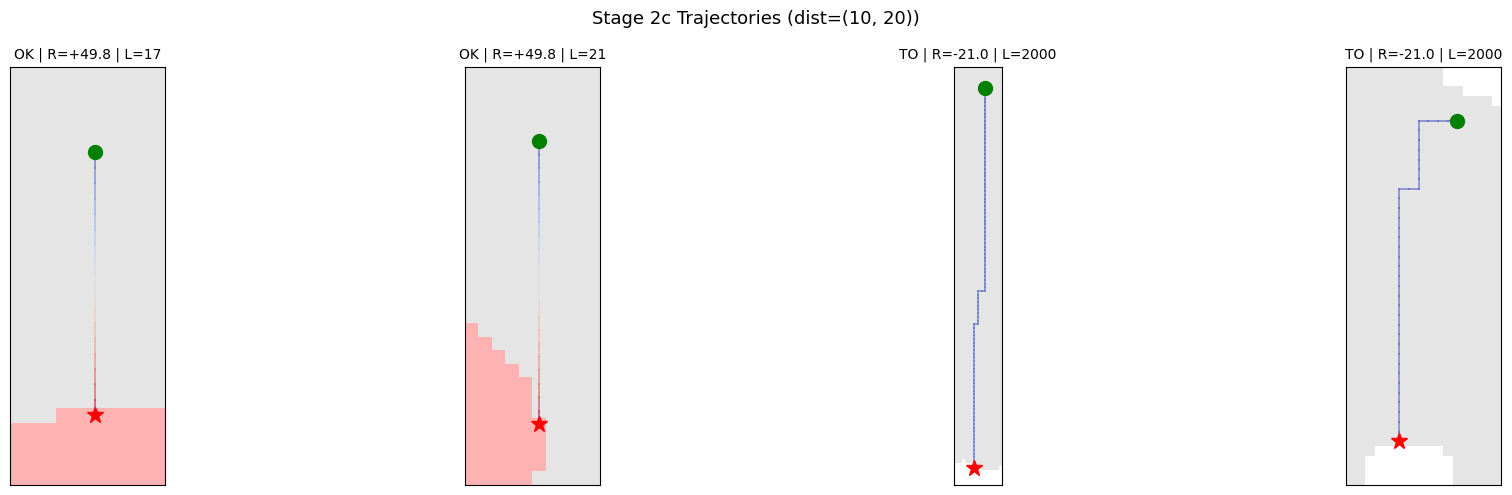

In [ ]:
# Stage 2c: evaluation & trajectory viz
results_2c = evaluate_from_pool(model_2c, H5_PATH, STAGE_2C_DIST, n_episodes=50)
sr_2c = np.mean([r["success"] for r in results_2c]) * 100
avg_l_2c = np.mean([r["length"] for r in results_2c])
avg_r_2c = np.mean([r["reward"] for r in results_2c])
print(f"Stage 2c eval (50 eps, dist={STAGE_2C_DIST}): "
      f"SR={sr_2c:.1f}%  avg_L={avg_l_2c:.1f}  avg_R={avg_r_2c:+.2f}")

# Forgetting check: test on 2a and 2b pools
results_2c_on_2a = evaluate_from_pool(model_2c, H5_PATH, STAGE_2A_DIST, n_episodes=50)
results_2c_on_2b = evaluate_from_pool(model_2c, H5_PATH, STAGE_2B_DIST, n_episodes=50)
sr_2c_on_2a = np.mean([r["success"] for r in results_2c_on_2a]) * 100
sr_2c_on_2b = np.mean([r["success"] for r in results_2c_on_2b]) * 100
print(f"Stage 2c model on 2a pool: SR={sr_2c_on_2a:.1f}% (was {sr_2a:.1f}%)")
print(f"Stage 2c model on 2b pool: SR={sr_2c_on_2b:.1f}% (was {sr_2b:.1f}%)")

grid_env_2c = env_2c.env if hasattr(env_2c, "env") else env_2c
plot_trajectories(results_2c, grid_env_2c, f"Stage 2c Trajectories (dist={STAGE_2C_DIST})", n_show=4)

In [ ]:
# Save Stage 2c model
save_path_2c = f"ppo_{RUN_TAG}_2c.zip"
model_2c.save(save_path_2c)
print(f"Stage 2c model saved: {save_path_2c}")

Stage 2c model saved: ppo_cur1_20260323_104751_2c.zip


## 6. Cross-Stage Summary

Evaluate each stage's model on all three distance pools to check for catastrophic forgetting.

Model               2a (3-5)    2b (5-10)   2c (10-20)
After 2a               56.0%        46.0%        34.0%
After 2b               58.0%        40.0%        24.0%
After 2c               52.0%        38.0%        44.0%



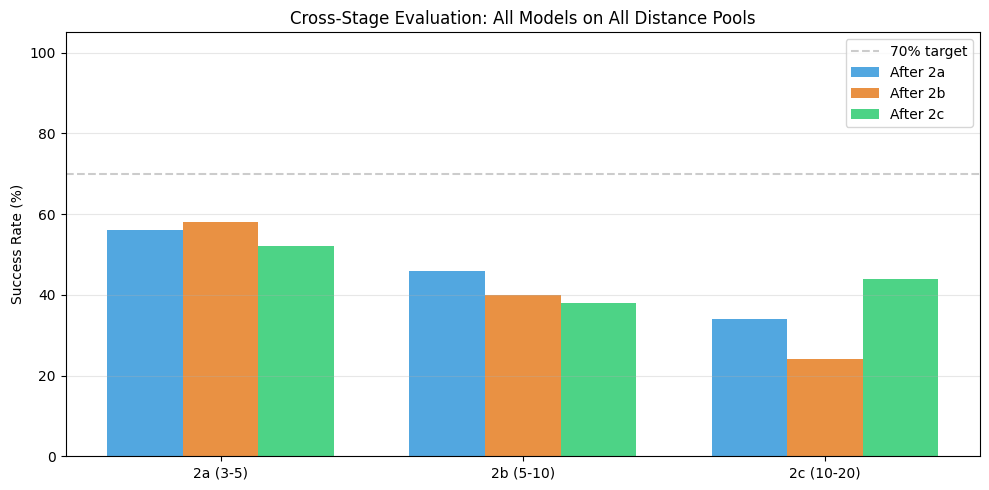


Training time summary:
  Stage 2a: 28.0 min (1M steps)
  Stage 2b: 27.4 min (1M steps)
  Stage 2c: 22.4 min (1M steps)
  Total   : 77.8 min


In [ ]:
# Cross-stage evaluation: each model on all 3 distance pools
dist_pools = [("2a (3-5)", STAGE_2A_DIST), ("2b (5-10)", STAGE_2B_DIST), ("2c (10-20)", STAGE_2C_DIST)]
models = [("After 2a", model_2a), ("After 2b", model_2b), ("After 2c", model_2c)]

cross_sr = {}
for model_name, model in models:
    cross_sr[model_name] = {}
    for pool_name, dist_range in dist_pools:
        res = evaluate_from_pool(model, H5_PATH, dist_range, n_episodes=50, seed=999)
        sr = np.mean([r["success"] for r in res]) * 100
        cross_sr[model_name][pool_name] = sr

# Print cross-stage table
header = f"{'Model':<15}"
for pool_name, _ in dist_pools:
    header += f" {pool_name:>12}"
print(header)
print("=" * len(header))
for model_name in cross_sr:
    row = f"{model_name:<15}"
    for pool_name, _ in dist_pools:
        row += f" {cross_sr[model_name][pool_name]:>11.1f}%"
    print(row)
print()

# Bar chart
x = np.arange(len(dist_pools))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#3498db", "#e67e22", "#2ecc71"]
for i, (model_name, _) in enumerate(models):
    srs = [cross_sr[model_name][pn] for pn, _ in dist_pools]
    ax.bar(x + i * width, srs, width, label=model_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([pn for pn, _ in dist_pools])
ax.set_ylabel("Success Rate (%)")
ax.set_title("Cross-Stage Evaluation: All Models on All Distance Pools")
ax.set_ylim(0, 105)
ax.axhline(70, color="gray", ls="--", alpha=0.4, label="70% target")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Training time summary
print(f"\nTraining time summary:")
print(f"  Stage 2a: {elapsed_2a/60:.1f} min ({STAGE_2A_STEPS/1e6:.0f}M steps)")
print(f"  Stage 2b: {elapsed_2b/60:.1f} min ({STAGE_2B_STEPS/1e6:.0f}M steps)")
print(f"  Stage 2c: {elapsed_2c/60:.1f} min ({STAGE_2C_STEPS/1e6:.0f}M steps)")
print(f"  Total   : {(elapsed_2a+elapsed_2b+elapsed_2c)/60:.1f} min")

## 7. Batch Trajectory Export (PNG)

Save one trajectory plot per episode for Stage 2b / 2c as PNG files, for closer inspection.

In [ ]:
# Batch trajectory PNG export for Stage 2b & 2c
N_BATCH = 30  # episodes per stage

def batch_eval_and_save(model, h5_path, dist_range, grid_env, out_dir,
                        n_episodes=30, max_steps=2000, seed=777):
    """Evaluate n_episodes and save each trajectory as an individual PNG."""
    os.makedirs(out_dir, exist_ok=True)

    eval_env = WSIEnv(
        h5_path=h5_path, max_steps=max_steps,
        embedding_suffix=EMBEDDING_SUFFIX, enable_stop=False,
        start_mode="distance_band", start_dist_range=dist_range,
    )

    rng = np.random.RandomState(seed)
    pool = eval_env.get_start_pool(dist_range[0], dist_range[1])
    indices = rng.choice(len(pool), size=min(n_episodes, len(pool)), replace=False)
    starts = [(int(pool[i][0]), int(pool[i][1])) for i in indices]

    n_ok, n_to = 0, 0
    for ep_i, start in enumerate(starts):
        eval_env.fixed_starts = [start]
        eval_env.start_mode = "fixed"
        eval_env._start_idx = 0

        obs, info = eval_env.reset()
        traj = [(info["row"], info["col"])]
        total_r, done = 0.0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            traj.append((info["row"], info["col"]))
            total_r += reward
            done = terminated or truncated

        success = info.get("success", False)
        length = len(traj) - 1
        if success:
            n_ok += 1
        else:
            n_to += 1

        # draw single trajectory
        traj_r = [t[0] for t in traj]
        traj_c = [t[1] for t in traj]
        margin = 8
        r_lo = max(0, min(traj_r) - margin)
        r_hi = min(grid_env.n_rows, max(traj_r) + margin)
        c_lo = max(0, min(traj_c) - margin)
        c_hi = min(grid_env.n_cols, max(traj_c) + margin)

        local_tissue = grid_env.tissue_grid[r_lo:r_hi, c_lo:c_hi]
        local_tumor  = grid_env.tumor_grid[r_lo:r_hi, c_lo:c_hi]
        canvas = np.ones((*local_tissue.shape, 3))
        canvas[local_tissue] = [0.92, 0.92, 0.92]
        canvas[local_tumor]  = [1.0, 0.72, 0.72]

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(canvas, origin="upper")

        sr = [r - r_lo for r in traj_r]
        sc = [c - c_lo for c in traj_c]
        n_seg = len(sr) - 1
        if n_seg > 0:
            cmap = plt.cm.coolwarm
            for s in range(n_seg):
                ax.plot(sc[s:s+2], sr[s:s+2],
                        color=cmap(s / max(n_seg - 1, 1)), alpha=0.6, lw=1.5)
        ax.plot(sc[0], sr[0], "go", ms=10, zorder=5, label="start")
        ax.plot(sc[-1], sr[-1], "r*", ms=14, zorder=5, label="end")

        # BFS distance of start
        d = grid_env._dist_to_tumor[start[0], start[1]] if grid_env._dist_to_tumor is not None else -1

        tag = "OK" if success else "TO"
        ax.set_title(f"ep{ep_i:02d} | {tag} | d={d} | R={total_r:+.1f} | L={length}", fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout()

        fname = f"ep{ep_i:02d}_{tag}_d{d}_L{length}.png"
        fig.savefig(os.path.join(out_dir, fname), dpi=120, bbox_inches="tight")
        plt.close(fig)

    eval_env.close()
    print(f"  Saved {n_episodes} PNGs -> {out_dir}/  (OK={n_ok}, TO={n_to}, SR={n_ok/n_episodes*100:.0f}%)")
    return n_ok, n_to


# ensure BFS is computed on grid envs
for ge in [grid_env_2b, grid_env_2c]:
    if ge._dist_to_tumor is None:
        ge._compute_distance_to_tumor()

# Stage 2b
out_2b = f"results/traj_batch_{RUN_TAG}_2b"
print(f"Stage 2b model, dist={STAGE_2B_DIST}, {N_BATCH} episodes:")
batch_eval_and_save(model_2b, H5_PATH, STAGE_2B_DIST, grid_env_2b,
                    out_2b, n_episodes=N_BATCH)

# Stage 2c
out_2c = f"results/traj_batch_{RUN_TAG}_2c"
print(f"Stage 2c model, dist={STAGE_2C_DIST}, {N_BATCH} episodes:")
batch_eval_and_save(model_2c, H5_PATH, STAGE_2C_DIST, grid_env_2c,
                    out_2c, n_episodes=N_BATCH)

print(f"\nDone. Check folders:\n  {out_2b}\n  {out_2c}")

Stage 2b model, dist=(5, 10), 30 episodes:
  Saved 30 PNGs -> results/traj_batch_cur1_20260323_104751_2b/  (OK=8, TO=22, SR=27%)
Stage 2c model, dist=(10, 20), 30 episodes:
  Saved 30 PNGs -> results/traj_batch_cur1_20260323_104751_2c/  (OK=14, TO=16, SR=47%)

Done. Check folders:
  results/traj_batch_cur1_20260323_104751_2b
  results/traj_batch_cur1_20260323_104751_2c
